## 01 - Data Profiling

This notebook focuses on understanding and profiling the raw Instacart datasets before data cleaning and analysis.

### Objectives
- Understand dataset structure
- Check data types
- Identify missing values
- Check duplicates
- Validate keys and relationships
- Understand data quality

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

## 1. Load Raw Datasets

The project contains six raw datasets:

1. Orders
2. Prior Order Products
3. Train Order Products
4. Products
5. Aisles
6. Departments

In [8]:
orders = pd.read_csv("D:/data analytics/Learning/End-to-End-Data-Analysis-Projects/Projects/Grocery_Demand_Customer_Intelligence/Data/Raw/orders.csv")
order_products_prior = pd.read_csv("D:/data analytics/Learning/End-to-End-Data-Analysis-Projects/Projects/Grocery_Demand_Customer_Intelligence/Data/Raw/order_products__prior.csv")
order_products_train = pd.read_csv("D:/data analytics/Learning/End-to-End-Data-Analysis-Projects/Projects/Grocery_Demand_Customer_Intelligence/Data/Raw/order_products__train.csv")
products = pd.read_csv("D:/data analytics/Learning/End-to-End-Data-Analysis-Projects/Projects/Grocery_Demand_Customer_Intelligence/Data/Raw/products.csv")
aisles = pd.read_csv("D:/data analytics/Learning/End-to-End-Data-Analysis-Projects/Projects/Grocery_Demand_Customer_Intelligence/Data/Raw/aisles.csv")
departments = pd.read_csv("D:/data analytics/Learning/End-to-End-Data-Analysis-Projects/Projects/Grocery_Demand_Customer_Intelligence/Data/Raw/departments.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


## 2. Dataset Overview

First, we will inspect the number of rows and columns in each dataset.

In [9]:
datasets = {
    "orders": orders,
    "order_products_prior": order_products_prior,
    "order_products_train": order_products_train,
    "products": products,
    "aisles": aisles,
    "departments": departments
}

overview = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

overview

,Dataset,Rows,Columns
0,orders,3421083,7
1,order_products_prior,32434489,4
2,order_products_train,1384617,4
3,products,49688,4
4,aisles,134,2
5,departments,21,2


In [10]:
for name, df in datasets.items():
    print(f"\n{'='*70}")
    print(f"{name.upper()}")
    print(f"{'='*70}")
    print(df.head())


ORDERS
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                   15.00  
2                   21.00  
3                   29.00  
4                   28.00  

ORDER_PRODUCTS_PRIOR
   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0
3         2       45918                  4          1
4         2       30035                  5          0

ORDER_PRODUCTS

## 3. Column and Data Type Analysis

We will inspect the columns and their data types for every dataset.

In [11]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 70)
    print(df.dtypes)


ORDERS
----------------------------------------------------------------------
order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

ORDER_PRODUCTS_PRIOR
----------------------------------------------------------------------
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object

ORDER_PRODUCTS_TRAIN
----------------------------------------------------------------------
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object

PRODUCTS
----------------------------------------------------------------------
product_id        int64
product_name     object
aisle_id          int64
department_id     int64
dtype: object

AISLES
----------------------------------------

In [12]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 70)
    display(df.info())


ORDERS
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB


None


ORDER_PRODUCTS_PRIOR
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB


None


ORDER_PRODUCTS_TRAIN
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           1384617 non-null  int64
 1   product_id         1384617 non-null  int64
 2   add_to_cart_order  1384617 non-null  int64
 3   reordered          1384617 non-null  int64
dtypes: int64(4)
memory usage: 42.3 MB


...

None


AISLES
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


None


DEPARTMENTS
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


None

In [13]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 70)
    df.info()


ORDERS
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB

ORDER_PRODUCTS_PRIOR
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory u

## 4. Missing Value Analysis

We will identify missing values and their percentage in each dataset.

In [14]:
missing_summary = []

for name, df in datasets.items():
    for column in df.columns:
        missing_count = df[column].isna().sum()
        missing_percentage = (missing_count / len(df)) * 100
        
        missing_summary.append({
            "Dataset": name,
            "Column": column,
            "Missing_Count": missing_count,
            "Missing_Percentage": missing_percentage
        })

missing_df = pd.DataFrame(missing_summary)

missing_df.sort_values(
    by="Missing_Percentage",
    ascending=False
)

,Dataset,Column,Missing_Count,Missing_Percentage
6,orders,days_since_prior_order,206209,6.03
0,orders,order_id,0,0.00
12,order_products_train,product_id,0,0.00
21,departments,department_id,0,0.00
20,aisles,aisle,0,0.00
19,aisles,aisle_id,0,0.00
18,products,department_id,0,0.00
17,products,aisle_id,0,0.00
16,products,product_name,0,0.00
15,products,product_id,0,0.00


## 5. Duplicate Analysis

We will check whether duplicate rows exist in the raw datasets.

In [15]:
duplicate_summary = []

for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    
    duplicate_summary.append({
        "Dataset": name,
        "Duplicate_Rows": duplicate_count,
        "Duplicate_Percentage": (duplicate_count / len(df)) * 100
    })

duplicates_df = pd.DataFrame(duplicate_summary)

duplicates_df

,Dataset,Duplicate_Rows,Duplicate_Percentage
0,orders,0,0.00
1,order_products_prior,0,0.00
2,order_products_train,0,0.00
3,products,0,0.00
4,aisles,0,0.00
5,departments,0,0.00


## 6. Unique Value Analysis

We will examine the number of unique values in important columns.

In [16]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 70)
    
    unique_counts = df.nunique().sort_values(ascending=False)
    display(unique_counts.to_frame("Unique_Values"))


ORDERS
----------------------------------------------------------------------


,Unique_Values
order_id,3421083
user_id,206209
order_number,100
days_since_prior_order,31
order_hour_of_day,24
order_dow,7
eval_set,3



ORDER_PRODUCTS_PRIOR
----------------------------------------------------------------------


,Unique_Values
order_id,3214874
product_id,49677
add_to_cart_order,145
reordered,2



ORDER_PRODUCTS_TRAIN
----------------------------------------------------------------------


...

,Unique_Values
product_id,49688
product_name,49688
aisle_id,134
department_id,21



AISLES
----------------------------------------------------------------------


,Unique_Values
aisle_id,134
aisle,134



DEPARTMENTS
----------------------------------------------------------------------


,Unique_Values
department_id,21
department,21


## 7. Key Validation

The datasets are connected through identifiers such as:

- order_id
- user_id
- product_id
- aisle_id
- department_id

We will validate these relationships before performing joins or analysis.

In [18]:
print("Orders - Unique order IDs:", orders["order_id"].nunique())
print("Orders - Total rows:", len(orders))

print("\nProducts - Unique product IDs:", products["product_id"].nunique())
print("Products - Total rows:", len(products))

print("\nAisles - Unique aisle IDs:", aisles["aisle_id"].nunique())
print("Aisles - Total rows:", len(aisles))

print("\nDepartments - Unique department IDs:", departments["department_id"].nunique())
print("Departments - Total rows:", len(departments))

Orders - Unique order IDs: 3421083
Orders - Total rows: 3421083

Products - Unique product IDs: 49688
Products - Total rows: 49688

Aisles - Unique aisle IDs: 134
Aisles - Total rows: 134

Departments - Unique department IDs: 21
Departments - Total rows: 21


In [19]:
print("Duplicate order IDs:", orders["order_id"].duplicated().sum())
print("Duplicate product IDs:", products["product_id"].duplicated().sum())
print("Duplicate aisle IDs:", aisles["aisle_id"].duplicated().sum())
print("Duplicate department IDs:", departments["department_id"].duplicated().sum())

Duplicate order IDs: 0
Duplicate product IDs: 0
Duplicate aisle IDs: 0
Duplicate department IDs: 0


## 8. Foreign Key Validation

We will check whether IDs in transactional tables exist in their respective dimension tables.

In [21]:
orders_order_ids = set(orders["order_id"])
product_ids = set(products["product_id"])
aisle_ids = set(aisles["aisle_id"])
department_ids = set(departments["department_id"])

prior_missing_orders = (~order_products_prior["order_id"].isin(orders_order_ids)).sum()
train_missing_orders = (~order_products_train["order_id"].isin(orders_order_ids)).sum()

product_missing_ids_prior = (~order_products_prior["product_id"].isin(product_ids)).sum()
product_missing_ids_train = (~order_products_train["product_id"].isin(product_ids)).sum()

print("Prior records with missing order_id:", prior_missing_orders)
print("Train records with missing order_id:", train_missing_orders)

print("Prior records with missing product_id:", product_missing_ids_prior)
print("Train records with missing product_id:", product_missing_ids_train)

Prior records with missing order_id: 0
Train records with missing order_id: 0
Prior records with missing product_id: 0
Train records with missing product_id: 0


In [22]:
product_missing_aisles = (~products["aisle_id"].isin(aisle_ids)).sum()
product_missing_departments = (~products["department_id"].isin(department_ids)).sum()

print("Products with invalid aisle_id:", product_missing_aisles)
print("Products with invalid department_id:", product_missing_departments)

Products with invalid aisle_id: 0
Products with invalid department_id: 0


## 9. Basic Statistical Profiling

We will inspect the numerical columns to understand their distributions and ranges.

In [23]:
orders.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,3421083.00,1710542.00,987581.74,1.00,855271.50,1710542.00,2565812.50,3421083.00
user_id,3421083.00,102978.21,59533.72,1.00,51394.00,102689.00,154385.00,206209.00
order_number,3421083.00,17.15,17.73,1.00,5.00,11.00,23.00,100.00
order_dow,3421083.00,2.78,2.05,0.00,1.00,3.00,5.00,6.00
order_hour_of_day,3421083.00,13.45,4.23,0.00,10.00,13.00,16.00,23.00
days_since_prior_order,3214874.00,11.11,9.21,0.00,4.00,7.00,15.00,30.00


In [24]:
order_products_prior.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,32434489.00,1710748.52,987300.70,2.00,855943.00,1711048.00,2565514.00,3421083.00
product_id,32434489.00,25576.34,14096.69,1.00,13530.00,25256.00,37935.00,49688.00
add_to_cart_order,32434489.00,8.35,7.13,1.00,3.00,6.00,11.00,145.00
reordered,32434489.00,0.59,0.49,0.00,0.00,1.00,1.00,1.00


In [25]:
order_products_train.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1384617.00,1706297.62,989732.65,1.00,843370.00,1701880.00,2568023.00,3421070.00
product_id,1384617.00,25556.24,14121.27,1.00,13380.00,25298.00,37940.00,49688.00
add_to_cart_order,1384617.00,8.76,7.42,1.00,3.00,7.00,12.00,80.00
reordered,1384617.00,0.60,0.49,0.00,0.00,1.00,1.00,1.00


## 10. Categorical Value Inspection

We will inspect important categorical and behavioral variables.

In [26]:
print("Evaluation sets:")
display(orders["eval_set"].value_counts())

print("\nOrder days:")
display(orders["order_dow"].value_counts().sort_index())

print("\nOrder hours:")
display(orders["order_hour_of_day"].value_counts().sort_index())

Evaluation sets:


eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64


Order days:


order_dow
0    600905
1    587478
2    467260
3    436972
4    426339
5    453368
6    448761
Name: count, dtype: int64


Order hours:


order_hour_of_day
0      22758
1      12398
2       7539
3       5474
4       5527
5       9569
6      30529
7      91868
8     178201
9     257812
10    288418
11    284728
12    272841
13    277999
14    283042
15    283639
16    272553
17    228795
18    182912
19    140569
20    104292
21     78109
22     61468
23     40043
Name: count, dtype: int64

## 11. Reorder Distribution

The `reordered` variable indicates whether a product was reordered by the customer.

In [27]:
print("Prior dataset:")
display(order_products_prior["reordered"].value_counts())

print("\nTrain dataset:")
display(order_products_train["reordered"].value_counts())

Prior dataset:


reordered
1    19126536
0    13307953
Name: count, dtype: int64


Train dataset:


reordered
1    828824
0    555793
Name: count, dtype: int64

In [28]:
reorder_summary = pd.DataFrame({
    "Prior": order_products_prior["reordered"].value_counts(normalize=True),
    "Train": order_products_train["reordered"].value_counts(normalize=True)
})

reorder_summary

,Prior,Train
reordered,,
1,0.59,0.60
0,0.41,0.40


## 12. Initial Behavioral Distribution

We will visualize when customers place their orders.

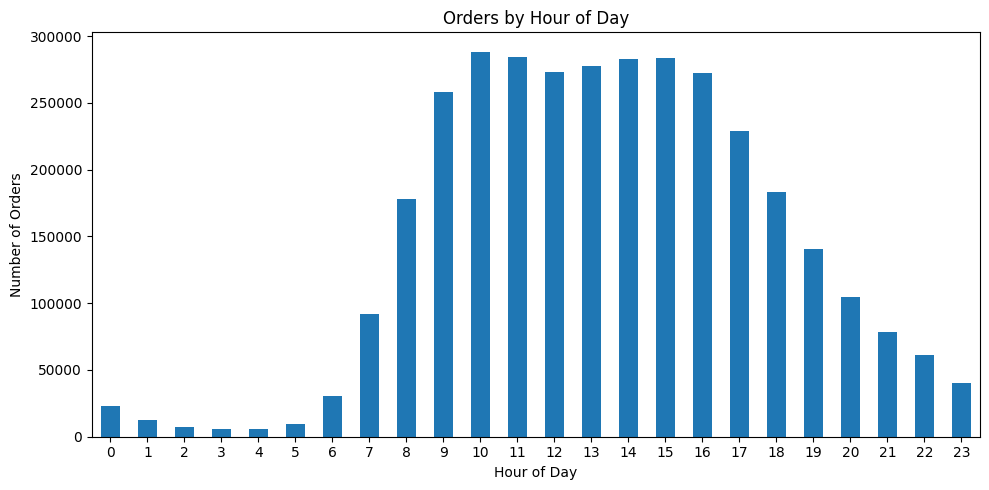

In [29]:
plt.figure(figsize=(10, 5))

orders["order_hour_of_day"].value_counts().sort_index().plot(kind="bar")

plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

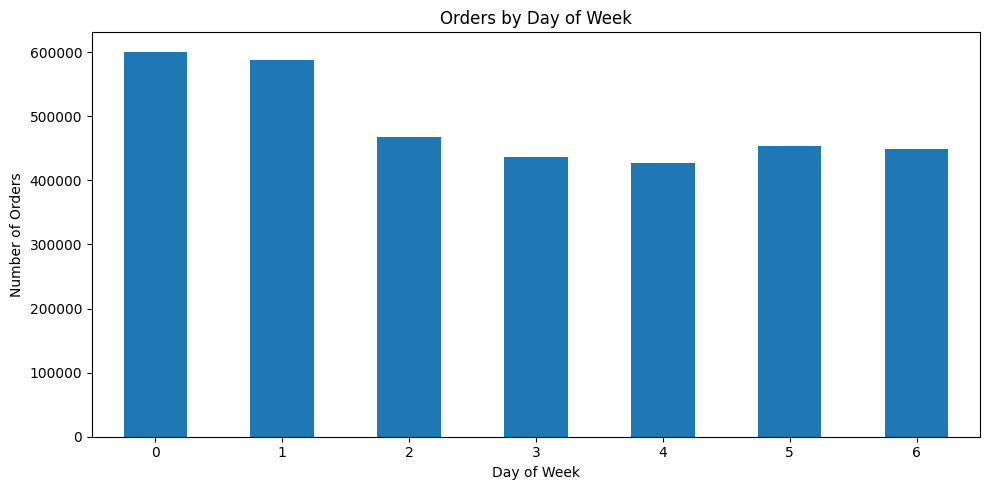

In [30]:
plt.figure(figsize=(10, 5))

orders["order_dow"].value_counts().sort_index().plot(kind="bar")

plt.title("Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Initial Findings

At this stage, we summarize observations from the raw data.

The findings documented here are exploratory observations only.
Data cleaning, feature engineering and detailed business analysis will be performed in subsequent notebooks.

In [31]:
print("Dataset Profiling Completed.")
print("\nDatasets analyzed:", len(datasets))

for name, df in datasets.items():
    print(f"- {name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset Profiling Completed.

Datasets analyzed: 6
- orders: 3,421,083 rows × 7 columns
- order_products_prior: 32,434,489 rows × 4 columns
- order_products_train: 1,384,617 rows × 4 columns
- products: 49,688 rows × 4 columns
- aisles: 134 rows × 2 columns
- departments: 21 rows × 2 columns


## 14. Next Steps

Based on the profiling results, the next notebook will focus on:

- Data cleaning
- Data type optimization
- Handling data quality issues
- Preparing processed datasets
- Saving cleaned data for downstream analysis

**Next Notebook:** `02_Data_Cleaning.ipynb`